In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# 1. Fetch from OpenML using the exact data ID (43939 is California Housing)
housing_bundle = fetch_openml(data_id=43939, as_frame=True, parser="auto")

# 2. Extract the combined dataframe (features + target)
df = housing_bundle.frame

# 3. Map OpenML columns to match standard scikit-learn metrics
# Note: Raw OpenML data has 'total_rooms', etc. We divide by households to get averages.
df['MedInc'] = df['median_income']
df['HouseAge'] = df['housing_median_age']
df['AveRooms'] = df['total_rooms'] / df['households']
df['AveBedrms'] = df['total_bedrooms'] / df['households']
df['Population'] = df['population']
df['AveOccup'] = df['population'] / df['households']
df['Latitude'] = df['latitude']
df['Longitude'] = df['longitude']
df['MedHouseVal'] = df['median_house_value'] / 100000.0  # Scale target to match sklearn standard ($100k blocks)

# Drop old columns and order them identically to the original fetch_california_housing
target_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
df = df[target_cols]

# Look at the first 5 rows of data
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


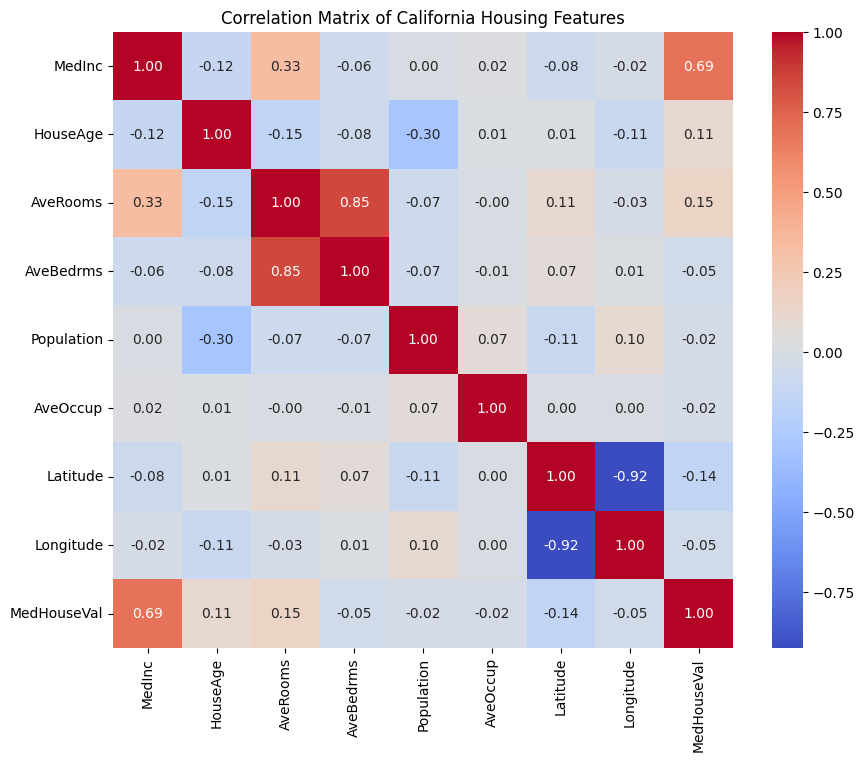

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# 1. Fetch from OpenML using the exact data ID (Bypasses the 403 error)
housing_bundle = fetch_openml(data_id=43939, as_frame=True, parser="auto")
df_raw = housing_bundle.frame

# 2. Replicate standard scikit-learn metrics/averages
df = pd.DataFrame()
df['MedInc'] = df_raw['median_income']
df['HouseAge'] = df_raw['housing_median_age']
df['AveRooms'] = df_raw['total_rooms'] / df_raw['households']
df['AveBedrms'] = df_raw['total_bedrooms'] / df_raw['households']
df['Population'] = df_raw['population']
df['AveOccup'] = df_raw['population'] / df_raw['households']
df['Latitude'] = df_raw['latitude']
df['Longitude'] = df_raw['longitude']
df['MedHouseVal'] = df_raw['median_house_value'] / 100000.0  # Scale target to match $100k blocks

# Ensure columns are in the expected order
target_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
df = df[target_cols]

# 3. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of California Housing Features")

# Save and show the image
plt.savefig('housing_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Fetch from OpenML
housing_bundle = fetch_openml(data_id=43939, as_frame=True, parser="auto")
df_raw = housing_bundle.frame

# 2. Replicate standard metrics
df = pd.DataFrame()
df['MedInc'] = df_raw['median_income']
df['HouseAge'] = df_raw['housing_median_age']
df['AveRooms'] = df_raw['total_rooms'] / df_raw['households']
df['AveBedrms'] = df_raw['total_bedrooms'] / df_raw['households']
df['Population'] = df_raw['population']
df['AveOccup'] = df_raw['population'] / df_raw['households']
df['Latitude'] = df_raw['latitude']
df['Longitude'] = df_raw['longitude']
df['MedHouseVal'] = df_raw['median_house_value'] / 100000.0

# Ensure standard column order
target_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
df = df[target_cols]

# === FIX: Drop the rows that contain missing values (NaN) ===
df = df.dropna()

# 3. Split features (X) from target prices (y)
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error (MAE): 0.540
Root Mean Squared Error (RMSE): 0.751
R² Score: 0.587


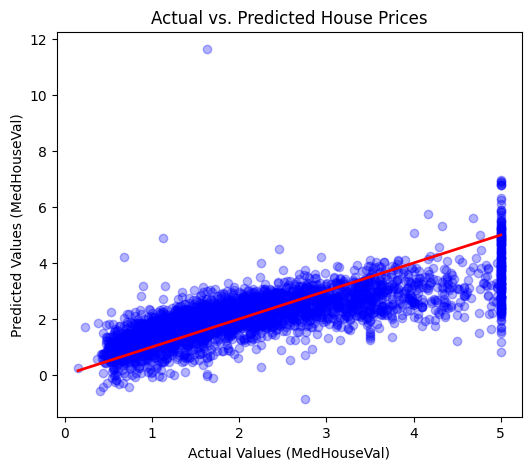

In [13]:
import matplotlib.pyplot as plt

# Create the scatter plot size
plt.figure(figsize=(6, 5))

# Plot the actual vs predicted data points
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')

# Draw the red line of perfect fit
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

# Label the axes and title
plt.xlabel("Actual Values (MedHouseVal)")
plt.ylabel("Predicted Values (MedHouseVal)")
plt.title("Actual vs. Predicted House Prices")

# ADDED LINE: This automatically saves the image as a file to your folder
plt.savefig('actual_vs_predicted_chart.png', dpi=300, bbox_inches='tight')

# Display the chart on your screen
plt.show()